<a href="https://colab.research.google.com/github/mohamed468/bertopic-arabic-news-evaluation/blob/main/BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantitative Evaluation & Benchmarking for BERTopic Topic Modeling

## Introduction
In this project, I built a topic modeling pipeline on a large Arabic news corpus
(~29K articles) using BERTopic, then added a quantitative evaluation and
benchmarking layer on top of it — moving beyond visual inspection of topics to
measure topic quality systematically using objective metrics and controlled
experimentation.

## What I Learned & Built
By the end of this project, I covered and implemented:

- **Reusable Pipeline Design:** Built a parameterized, reusable BERTopic pipeline
  function to support repeated, controlled experimentation.
- **Quantitative Topic Evaluation:** Implemented topic coherence (c_v), topic
  diversity, and outlier ratio as objective quality signals instead of relying
  on visual inspection alone.
- **Controlled Experimentation (OFAT):** Designed a One-Factor-At-a-Time
  experiment comparing 5 configurations (UMAP/HDBSCAN hyperparameters and
  embedding model choice) to isolate the effect of each factor.
- **Embedding Model Benchmarking:** Found that the choice of embedding model
  (LaBSE vs. distiluse) affected topic coherence more than any clustering
  hyperparameter tested.
- **Critical Result Interpretation:** Manually inspected topics to catch a
  metric-inflation issue caused by Arabic's rich morphology, instead of trusting
  a high coherence score at face value.

## Who Should Explore This
This notebook is aimed at:

- **NLP Practitioners** working with unsupervised topic modeling who want to
  move past "the topics look reasonable" evaluation.
- **Arabic NLP Practitioners** dealing with morphologically rich text and its
  effect on standard NLP metrics.
- **ML Engineers** interested in designing small, defensible experiments
  (OFAT) instead of large, costly grid searches.

**Author:**
- [Muhammad Abd El-Fattah](https://www.linkedin.com/in/mohamed456/) | [GitHub Profile](https://github.com/mohamed468)

In [1]:
!pip install bertopic==0.16.0 datasets==2.16.1 Arabic-Stopwords==0.4.3

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.1/154.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 15.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.12.0
    Uninstalling fsspec-2025.12.0:
      Successfully uninstalled fsspec-2025.12.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully

In [2]:
from datasets import load_dataset
import pandas as pd

import re
import random
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
def clean_text(text: str):
  if not isinstance(text, str):
    return ""

  # remove urls
  text = re.sub(r"http\S+"," رابط",text)
  # replace any digit with رقم
  text = re.sub(r"\d"," رقم ", text)
  # set space before and after any punctuation
  text = re.sub(r"([^\w\s])", r" \1 ", text)
  # remove extra spaces
  text = re.sub(r"\s+"," ", text)

  words = word_tokenize(text)
  text = " ".join([w for w in words if len(w)>1])

  return text.lower().strip()

In [4]:
ar_dataset = load_dataset("inparallel/saudinewsnet")

/usr/local/lib/python3.13/dist-packages/datasets/load.py:1429: FutureWarning: The repository for inparallel/saudinewsnet contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/inparallel/saudinewsnet
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/31030 [00:00<?, ? examples/s]

In [5]:
ar_dataset

DatasetDict({
    train: Dataset({
        features: ['source', 'url', 'date_extracted', 'title', 'author', 'content'],
        num_rows: 31030
    })
})

In [7]:
ar_dataset['train'][0]

{'source': 'aawsat',
 'url': 'http://aawsat.com/home/article/410826/بريطانيا-أربعة-محاور-لاستراتيجية-جديدة-تتصدى-للتطرف-على-مدى-خمس-سنوات',
 'date_extracted': '2015-07-21 02:51:32',
 'title': 'بريطانيا: أربعة محاور لاستراتيجية جديدة تتصدى للتطرف على مدى خمس سنوات',
 'author': 'لندن: رنيم حنوش',
 'content': 'حدد رئيس الوزراء البريطاني ديفيد كاميرون، اليوم (الاثنين)، ملامح استراتيجية للتصدي للتطرف داخل بريطانيا؛ وهي مسألة اعتبرها كاميرون "صراع جيلنا"، متعهدا خلال خطابه في مدينة بيرمنغهام بالتصدي لهؤلاء الذين ينشرون التطرف بين الشبان المسلمين البريطانيين.\n\n ورسم كاميرون الاطار العام لاستراتيجية مكافحة التطرف التي المقرر ان تنشر كاملة في وقت لاحق هذا العام، والتي تسعى للتصدي لانتشار الأفكار المتطرفة التي يروج لها متشددو تنظيم "داعش".\n\n وحسبما تناقلت وسائل الإعلام البريطانية، فإن خطة رئيس الوزراء ستكون على مدى خمسة أعوام للقضاء على التطرف الداخلي من خلال أربعة محاور، وهي: القضاء على إيديولوجية التطرف، والوقوف في وجه عمليات التجنيد وغسل الأدمغة بالأفكار المتطرفة، وإعادة اصوات الاسلام الم

In [8]:
raw_dataset = [
    {
        "text" : rec["content"],
        "source":rec["source"],
        "date":rec["date_extracted"]
    }
    for rec in ar_dataset['train']
]


# raw_data = ar_dataset['train'].select_columns(['content','date_extracted','source'])

In [9]:
raw_dataset[0]

{'text': 'حدد رئيس الوزراء البريطاني ديفيد كاميرون، اليوم (الاثنين)، ملامح استراتيجية للتصدي للتطرف داخل بريطانيا؛ وهي مسألة اعتبرها كاميرون "صراع جيلنا"، متعهدا خلال خطابه في مدينة بيرمنغهام بالتصدي لهؤلاء الذين ينشرون التطرف بين الشبان المسلمين البريطانيين.\n\n ورسم كاميرون الاطار العام لاستراتيجية مكافحة التطرف التي المقرر ان تنشر كاملة في وقت لاحق هذا العام، والتي تسعى للتصدي لانتشار الأفكار المتطرفة التي يروج لها متشددو تنظيم "داعش".\n\n وحسبما تناقلت وسائل الإعلام البريطانية، فإن خطة رئيس الوزراء ستكون على مدى خمسة أعوام للقضاء على التطرف الداخلي من خلال أربعة محاور، وهي: القضاء على إيديولوجية التطرف، والوقوف في وجه عمليات التجنيد وغسل الأدمغة بالأفكار المتطرفة، وإعادة اصوات الاسلام المعتدل إلى المجتمع البريطاني، والتعامل مع أزمات الهوية التي يواجهها بعض المسلمين المولودين في بريطانيا.\n\n وسيكون من الأهداف الرئيسية للاستراتيجية مكافحة صعود من يطلق عليهم اسم "متطرفي الداخل"، وهو أمر يقول كاميرون انه لا يمكن عمله دون فهم الاسباب التي تجتذب الناس لـ"داعش" والتصدي لها. إذ قال كاميرو

In [10]:
raw_dataset_df = pd.DataFrame(raw_dataset)
raw_dataset_df = raw_dataset_df.sample(frac=1, random_state=101)
raw_dataset_df.shape

(31030, 3)

In [11]:
raw_dataset_df.head()

,text,source,date
26442,عين اليوم – الدمام\n عقدت أمانة المنطقة الشرق...,3alyoum,2015-08-09 20:45:39
24574,"""لم نر الإرهاب إلا بعد تسييس الدين، ليصير الو...",alwatan,2015-08-07 06:32:39
20441,رغد عشميل – عين اليوم\n عزز فريق ريال مدريد ا...,3alyoum,2015-08-06 19:16:04
7927,أوضحت إدارة مستشفى الدوادمي العام في بيان ...,alriyadh,2015-07-24 16:23:27
14012,الشعر الجميل يبقى محفوراً في الذاكرة لا يم...,alriyadh,2015-07-31 03:53:17


In [12]:
raw_dataset_df['text'] = raw_dataset_df['text'].apply(clean_text)

In [13]:
raw_dataset_df['text_length'] = raw_dataset_df['text'].apply(len)

In [14]:
raw_dataset_df.head(2)

,text,source,date,text_length
26442,عين اليوم الدمام عقدت أمانة المنطقة الشرقية ال...,3alyoum,2015-08-09 20:45:39,1094
24574,`` لم نر الإرهاب إلا بعد تسييس الدين ليصير الو...,alwatan,2015-08-07 06:32:39,3402


<Axes: xlabel='text_length', ylabel='Count'>

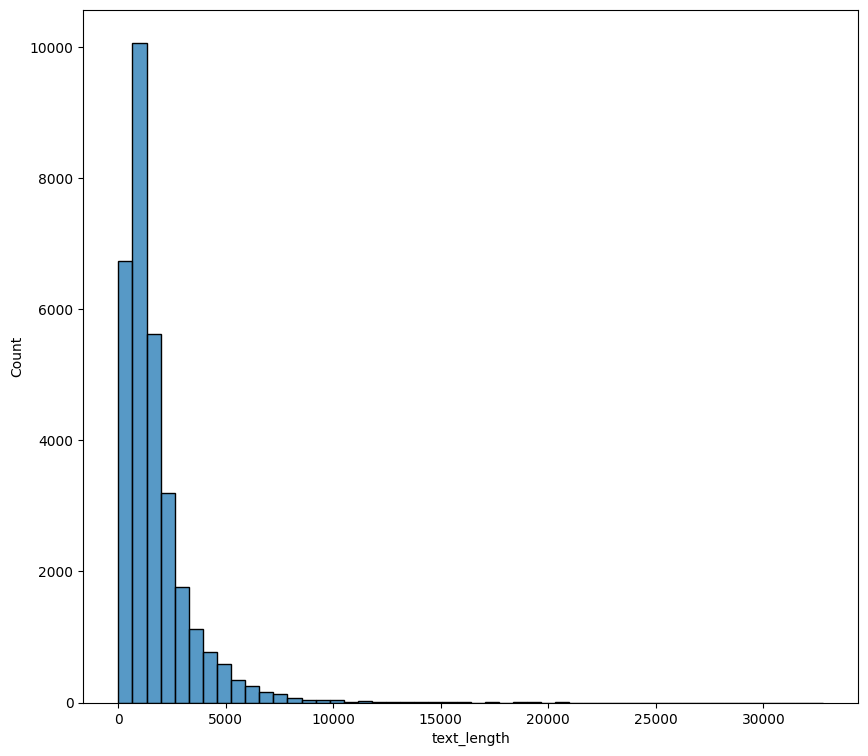

In [15]:
plt.figure(figsize=(10,9))
sns.histplot(raw_dataset_df["text_length"], bins=50)

In [16]:
print(raw_dataset_df.shape)
raw_dataset_df = raw_dataset_df[raw_dataset_df['text_length'] <= 10_000]
print(raw_dataset_df.shape)


(31030, 4)
(30891, 4)


In [17]:
print(raw_dataset_df.shape)
raw_dataset_df.drop_duplicates(['text'], inplace= True)
print(raw_dataset_df.shape)


(30891, 4)
(29681, 4)


In [18]:
raw_dataset_df['datetime_stamp'] = raw_dataset_df['date'].apply(lambda v: datetime.strptime(v, "%Y-%m-%d %H:%M:%S"))

raw_dataset_df['datetime_stamp'] = raw_dataset_df['datetime_stamp'].apply(lambda v: v.replace(hour=0, minute=0, second=0))

## Embedding

In [20]:
from sentence_transformers import SentenceTransformer

model_id = "sentence-transformers/LaBSE"
embedding_model = SentenceTransformer(model_id, device="cuda:0")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [21]:
news_embeddings = embedding_model.encode(raw_dataset_df['text'].values, show_progress_bar=True)


Batches:   0%|          | 0/928 [00:00<?, ?it/s]

In [22]:
news_embeddings.shape

(29681, 768)

In [23]:
raw_dataset_df['text'][0]

'حدد رئيس الوزراء البريطاني ديفيد كاميرون اليوم الاثنين ملامح استراتيجية للتصدي للتطرف داخل بريطانيا وهي مسألة اعتبرها كاميرون `` صراع جيلنا `` متعهدا خلال خطابه في مدينة بيرمنغهام بالتصدي لهؤلاء الذين ينشرون التطرف بين الشبان المسلمين البريطانيين ورسم كاميرون الاطار العام لاستراتيجية مكافحة التطرف التي المقرر ان تنشر كاملة في وقت لاحق هذا العام والتي تسعى للتصدي لانتشار الأفكار المتطرفة التي يروج لها متشددو تنظيم `` داعش `` وحسبما تناقلت وسائل الإعلام البريطانية فإن خطة رئيس الوزراء ستكون على مدى خمسة أعوام للقضاء على التطرف الداخلي من خلال أربعة محاور وهي القضاء على إيديولوجية التطرف والوقوف في وجه عمليات التجنيد وغسل الأدمغة بالأفكار المتطرفة وإعادة اصوات الاسلام المعتدل إلى المجتمع البريطاني والتعامل مع أزمات الهوية التي يواجهها بعض المسلمين المولودين في بريطانيا وسيكون من الأهداف الرئيسية للاستراتيجية مكافحة صعود من يطلق عليهم اسم `` متطرفي الداخل `` وهو أمر يقول كاميرون انه لا يمكن عمله دون فهم الاسباب التي تجتذب الناس لـ `` داعش `` والتصدي لها إذ قال كاميرون في سياق خطابه `` عند

In [24]:
news_embeddings[0]

array([-1.67960413e-02, -4.62577939e-02, -2.86064390e-02,  6.65430212e-03,
       -7.20104352e-02,  4.96060923e-02, -2.71093715e-02,  4.14116979e-02,
        4.93271910e-02,  7.37262378e-03, -3.35612968e-02, -2.49696076e-02,
       -4.99700531e-02,  5.92021830e-02,  9.06411372e-03,  2.15223450e-02,
        3.58014815e-02, -3.42024751e-02, -3.06137633e-02,  3.37783433e-02,
        4.24083509e-02, -6.55443668e-02, -5.98193333e-02,  3.90620865e-02,
        2.26926990e-02, -4.46792208e-02, -2.69029476e-02,  7.52605870e-03,
       -1.99561287e-03, -7.08163977e-02,  3.95765752e-02, -2.52100956e-02,
       -6.27186475e-03, -8.11925856e-05, -3.74609381e-02, -4.73334081e-02,
       -7.36772865e-02, -2.95348335e-02,  4.17762399e-02, -3.81801724e-02,
        6.58031702e-02, -6.00677878e-02, -7.45499656e-02,  1.97073212e-03,
       -3.84626426e-02, -3.86687219e-02, -2.37264410e-02, -1.48796476e-02,
       -4.18655090e-02, -5.30618839e-02, -8.66776146e-03, -1.27885872e-02,
        5.03199399e-02,  

In [25]:
!pip install gensim==4.4.0 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.6 MB/s eta 0:00:00


## pipeline function

In [26]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import arabicstopwords.arabicstopwords as stp
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

def run_bertopic_pipeline(
    documents,
    embeddings,
    embedding_model,
    n_neighbors=15,
    min_cluster_size=50,
    random_state=101,
    verbose=True
):
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=15,
        min_dist=0.0,
        metric="cosine",
        random_state=random_state
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )

    stop_words = stp.stopwords_list()
    vectorizer_model = CountVectorizer(
        min_df=3,
        stop_words=stop_words,
        analyzer="word",
        max_df=0.5,
        ngram_range=(1, 3)
    )

    representation_model = {
        "Main": KeyBERTInspired()
    }

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        top_n_words=10,
        verbose=verbose
    )

    topics, probabilities = topic_model.fit_transform(documents, embeddings)

    return topic_model, topics, probabilities

## Training

In [27]:
topic_model, topics, probabilities = run_bertopic_pipeline(
    documents=raw_dataset_df['text'].values,
    embeddings=news_embeddings,
    embedding_model=embedding_model,
    n_neighbors=15,
    min_cluster_size=50,
    random_state=101,
    verbose=True
)

2026-09-27 10:01:47,688 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-27 10:03:50,083 - BERTopic - Dimensionality - Completed ✓
2026-09-27 10:03:50,086 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-27 10:03:58,784 - BERTopic - Cluster - Completed ✓
2026-09-27 10:03:58,801 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-09-27 10:05:19,038 - BERTopic - Representation - Completed ✓


In [28]:
topics[50], probabilities[50]

(21, np.float64(0.800304580286721))

In [29]:
raw_dataset_df['topic'] = topics
raw_dataset_df['probability'] = probabilities

## metrics

In [30]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import numpy as np

tokenized_docs = [doc.split() for doc in raw_dataset_df['text'].values]
dictionary = Dictionary(tokenized_docs)

def get_topic_words(topic_model, top_n=10):
    topic_info = topic_model.get_topic_info()
    valid_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()

    topic_words = []
    for topic_id in valid_topics:
        words_scores = topic_model.get_topic(topic_id)
        if words_scores:
            words = [w for w, _ in words_scores if " " not in w][:top_n]
            if words:
                topic_words.append(words)

    return topic_words

def compute_topic_diversity(topic_words):
    if len(topic_words) == 0:
        return 0.0

    all_words = [word for topic in topic_words for word in topic]
    if len(all_words) == 0:
        return 0.0

    return len(set(all_words)) / len(all_words)

def evaluate_topic_model(topic_model, topics, tokenized_docs, dictionary, top_n=10):
    topic_words = get_topic_words(topic_model, top_n=top_n)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence = coherence_model.get_coherence()

    diversity = compute_topic_diversity(topic_words)

    topics_array = np.array(topics)
    valid_topics = [t for t in np.unique(topics_array) if t != -1]
    n_topics = len(valid_topics)
    outlier_ratio = (topics_array == -1).mean()

    return {
        "coherence": coherence,
        "diversity": diversity,
        "n_topics": n_topics,
        "outlier_ratio": outlier_ratio
    }

## baseline

In [31]:
baseline_metrics = evaluate_topic_model(
    topic_model=topic_model,
    topics=topics,
    tokenized_docs=tokenized_docs,
    dictionary=dictionary,
    top_n=10
)

baseline_metrics

{'coherence': np.float64(0.864870025700085),
 'diversity': 0.9269102990033222,
 'n_topics': 92,
 'outlier_ratio': np.float64(0.3299080219669149)}

In [32]:
# Coherence (0.86) is unusually high. Manual inspection below suggests Arabic's rich
# morphology (لاعب/لاعبين/اللاعبين) inflates the score — a documented limitation, not fixed here.

for topic_id in [0, 1, 2]:
    print(topic_id, topic_model.get_topic(topic_id))

0 [('لاعبي', np.float32(0.25322914)), ('النادي الأهلي', np.float32(0.24803188)), ('للاعبين', np.float32(0.24632455)), ('اللاعبين', np.float32(0.24570492)), ('الأول لكرة القدم', np.float32(0.24442571)), ('لاعبين', np.float32(0.24391285)), ('اللاعب', np.float32(0.24352059)), ('الفريق الأول لكرة', np.float32(0.24066341)), ('المدرب', np.float32(0.23941493)), ('مدرب', np.float32(0.23237664))]
1 [('الاتفاق النووي إيران', np.float32(0.39813894)), ('الاتفاق النووي', np.float32(0.29911187)), ('باراك أوباما', np.float32(0.259731)), ('وإيران', np.float32(0.24966943)), ('أوباما', np.float32(0.2308645)), ('طهران', np.float32(0.2265532)), ('النووي الإيراني', np.float32(0.22556841)), ('لإيران', np.float32(0.22273374)), ('النووي إيران', np.float32(0.21991771)), ('ايران', np.float32(0.21923657))]
2 [('مانشستر سيتي', np.float32(0.3400486)), ('تشيلسي', np.float32(0.29634702)), ('سان جيرمان', np.float32(0.2932701)), ('الدوري الإنجليزي', np.float32(0.28880244)), ('مانشستر', np.float32(0.2879882)), ('يونايت

## experiment configs

In [33]:
# Experiment design: One-Factor-At-a-Time (OFAT) — each config changes exactly one
# hyperparameter from baseline to isolate its individual effect, not a full grid search.

experiment_configs = [
    {"config_name": "baseline", "n_neighbors": 15, "min_cluster_size": 50},
    {"config_name": "umap_10",  "n_neighbors": 10, "min_cluster_size": 50},
    {"config_name": "umap_30",  "n_neighbors": 30, "min_cluster_size": 50},
    {"config_name": "hdbscan_25", "n_neighbors": 15, "min_cluster_size": 25},
]

## Experiment

In [34]:
results = []

for config in experiment_configs:
    print(f"Running: {config['config_name']}")

    exp_topic_model, exp_topics, exp_probabilities = run_bertopic_pipeline(
    documents=raw_dataset_df['text'].values,
        embeddings=news_embeddings,
        embedding_model=embedding_model,
        n_neighbors=config["n_neighbors"],
        min_cluster_size=config["min_cluster_size"],
        random_state=101,
        verbose=False
    )

    metrics = evaluate_topic_model(
        topic_model=exp_topic_model,
        topics=exp_topics,
        tokenized_docs=tokenized_docs,
        dictionary=dictionary,
        top_n=10
    )

    results.append({
        "config_name": config["config_name"],
        "n_neighbors": config["n_neighbors"],
        "min_cluster_size": config["min_cluster_size"],
        "coherence": metrics["coherence"],
        "diversity": metrics["diversity"],
        "n_topics": metrics["n_topics"],
        "outlier_ratio": metrics["outlier_ratio"]
    })

results_df = pd.DataFrame(results)
results_df

Running: baseline
Running: umap_10
Running: umap_30
Running: hdbscan_25


,config_name,n_neighbors,min_cluster_size,coherence,diversity,n_topics,outlier_ratio
0,baseline,15,50,0.864870,0.926910,92,0.329908
1,umap_10,10,50,0.832318,0.941980,85,0.296284
2,umap_30,30,50,0.877780,0.953846,65,0.229406
3,hdbscan_25,15,25,0.861058,0.871269,188,0.379367


## Results

In [35]:
results_df = results_df.sort_values("coherence", ascending=False).reset_index(drop=True)
results_df

,config_name,n_neighbors,min_cluster_size,coherence,diversity,n_topics,outlier_ratio
0,umap_30,30,50,0.877780,0.953846,65,0.229406
1,baseline,15,50,0.864870,0.926910,92,0.329908
2,hdbscan_25,15,25,0.861058,0.871269,188,0.379367
3,umap_10,10,50,0.832318,0.941980,85,0.296284


## visualization

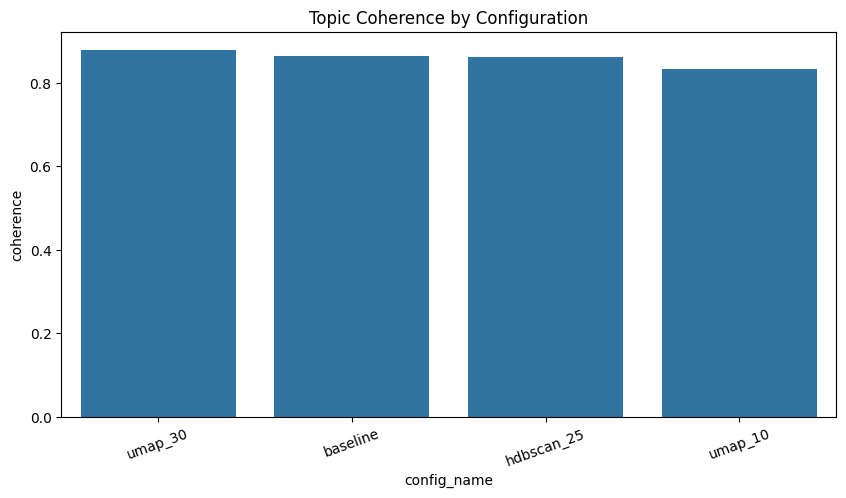

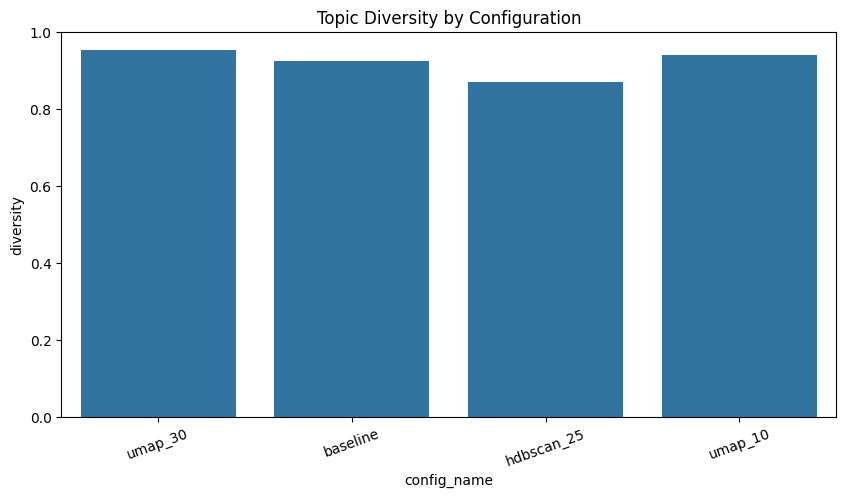

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="config_name", y="coherence")
plt.title("Topic Coherence by Configuration")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="config_name", y="diversity")
plt.title("Topic Diversity by Configuration")
plt.xticks(rotation=20)
plt.show()

## embedding swap

In [37]:
distiluse_model_id = "sentence-transformers/distiluse-base-multilingual-cased-v2"
distiluse_embedding_model = SentenceTransformer(distiluse_model_id, device="cuda:0")

distiluse_embeddings = distiluse_embedding_model.encode(
    raw_dataset_df['text'].values,
    show_progress_bar=True
)

embedding_topic_model, embedding_topics, embedding_probabilities = run_bertopic_pipeline(
    documents=raw_dataset_df['text'].values,
    embeddings=distiluse_embeddings,
    embedding_model=distiluse_embedding_model,
    n_neighbors=15,
    min_cluster_size=50,
    random_state=101,
    verbose=True
)

embedding_metrics = evaluate_topic_model(
    topic_model=embedding_topic_model,
    topics=embedding_topics,
    tokenized_docs=tokenized_docs,
    dictionary=dictionary,
    top_n=10
)

results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "config_name": "embedding_distiluse",
        "n_neighbors": 15,
        "min_cluster_size": 50,
        "coherence": embedding_metrics["coherence"],
        "diversity": embedding_metrics["diversity"],
        "n_topics": embedding_metrics["n_topics"],
        "outlier_ratio": embedding_metrics["outlier_ratio"]
    }])
], ignore_index=True)

results_df

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.46k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/610 [00:00<?, ?B/s]

...

2_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 1.58MB            

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

Batches:   0%|          | 0/928 [00:00<?, ?it/s]

2026-09-27 10:22:10,693 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-27 10:22:58,524 - BERTopic - Dimensionality - Completed ✓
2026-09-27 10:22:58,526 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-27 10:23:08,947 - BERTopic - Cluster - Completed ✓
2026-09-27 10:23:08,958 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-09-27 10:24:16,848 - BERTopic - Representation - Completed ✓


,config_name,n_neighbors,min_cluster_size,coherence,diversity,n_topics,outlier_ratio
0,umap_30,30,50,0.877780,0.953846,65,0.229406
1,baseline,15,50,0.864870,0.926910,92,0.329908
2,hdbscan_25,15,25,0.861058,0.871269,188,0.379367
3,umap_10,10,50,0.832318,0.941980,85,0.296284
4,embedding_distiluse,15,50,0.932064,0.945205,81,0.342071


In [38]:
embedding_topic_model.visualize_barchart()

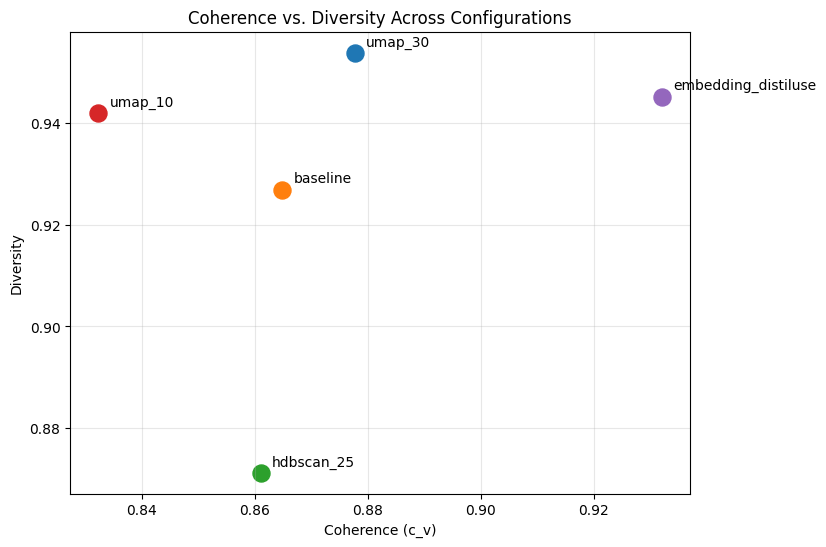

In [39]:
plt.figure(figsize=(8, 6))
for _, row in results_df.iterrows():
    plt.scatter(row['coherence'], row['diversity'], s=150)
    plt.annotate(row['config_name'],
                 (row['coherence'], row['diversity']),
                 textcoords="offset points", xytext=(8, 5), fontsize=10)
plt.xlabel("Coherence (c_v)")
plt.ylabel("Diversity")
plt.title("Coherence vs. Diversity Across Configurations")
plt.grid(alpha=0.3)
plt.show()

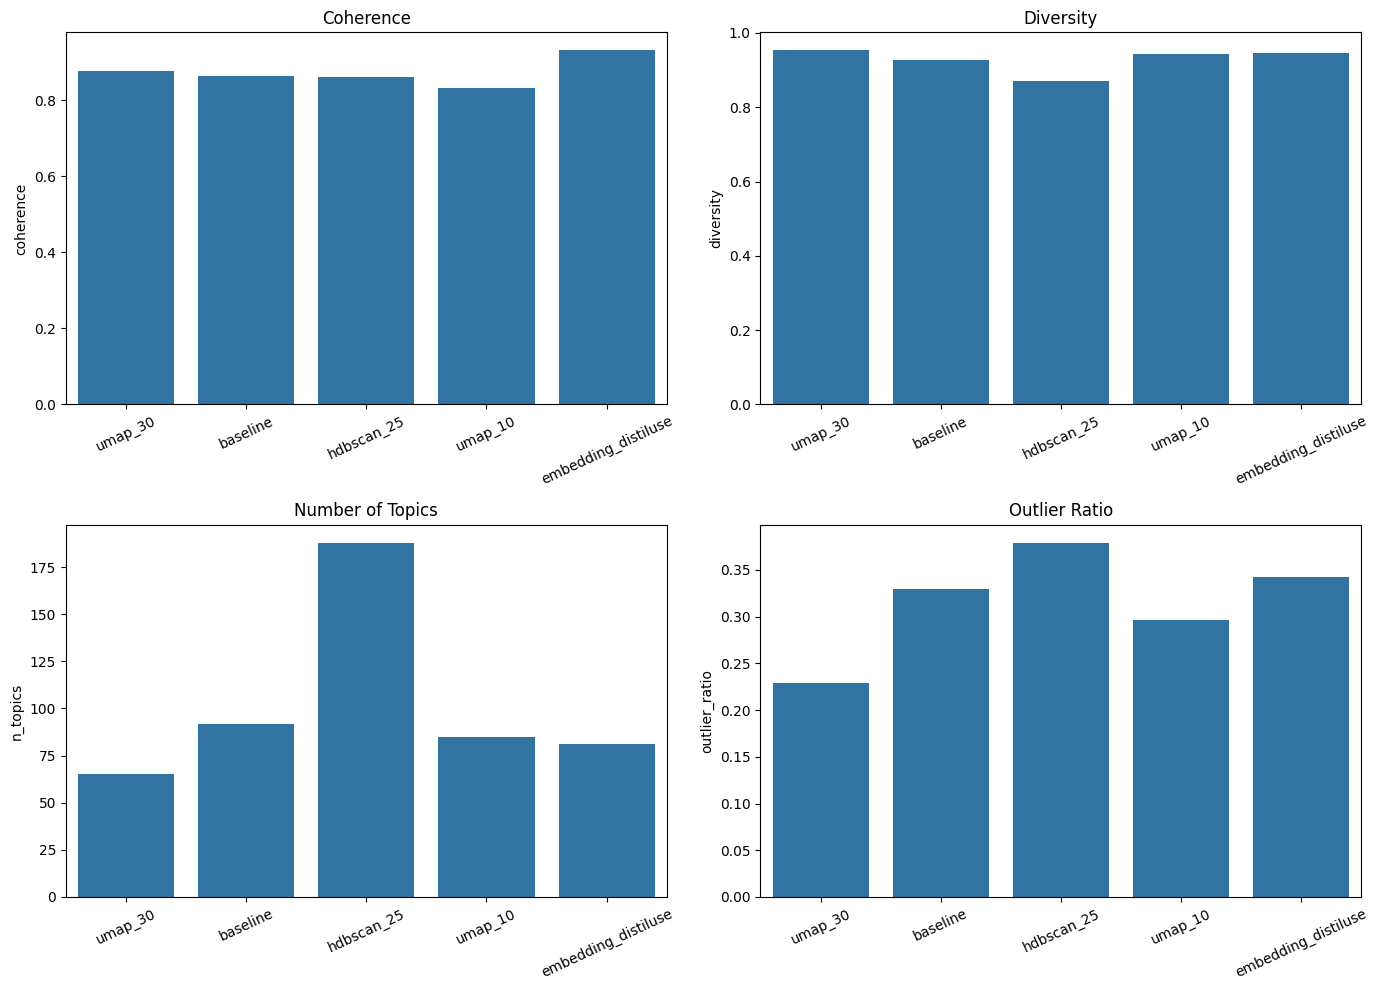

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['coherence', 'diversity', 'n_topics', 'outlier_ratio']
titles = ['Coherence', 'Diversity', 'Number of Topics', 'Outlier Ratio']

for ax, metric, title in zip(axes.flat, metrics_to_plot, titles):
    sns.barplot(data=results_df, x='config_name', y=metric, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=25)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [41]:
!pip install arabic-reshaper python-bidi --no-deps -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 9.9 MB/s eta 0:00:00


In [42]:
import arabic_reshaper
from bidi.algorithm import get_display

def fix_ar(text):
    return get_display(arabic_reshaper.reshape(text))

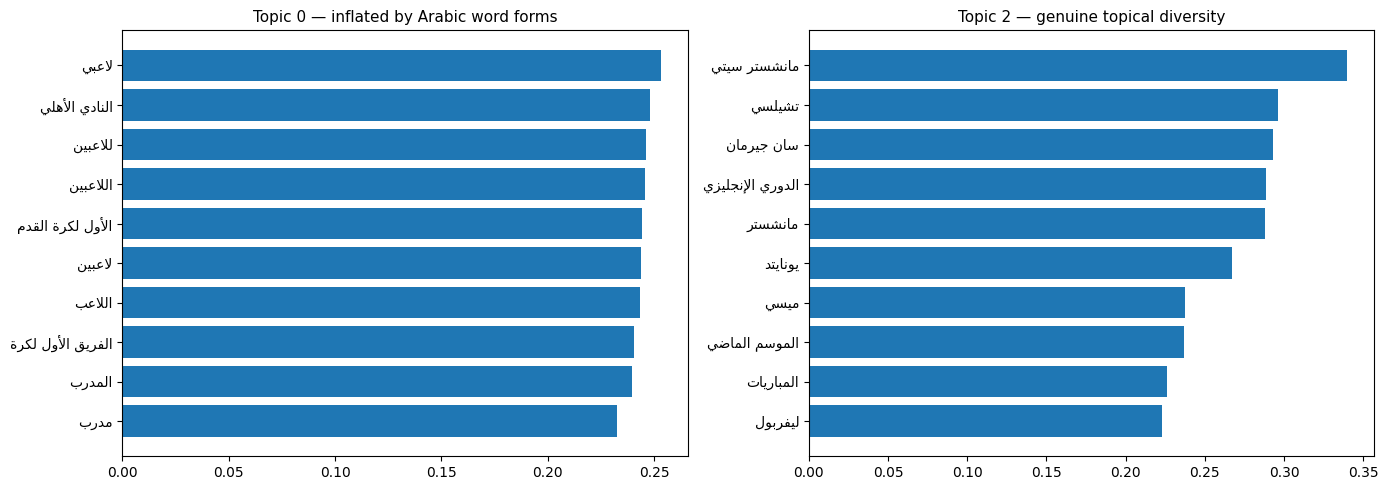

In [43]:
# Key Findings & Limitations
# - Embedding model choice (LaBSE vs. distiluse) affected coherence more than any
#   UMAP/HDBSCAN hyperparameter tested.
# - No single config wins on all four metrics: embedding_distiluse led on coherence,
#   umap_30 led on outlier ratio — a real trade-off, not a clean winner.
# - OFAT does not capture interaction effects (e.g. embedding model + n_neighbors
#   combined) — a natural extension for future work.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, topic_id, title in zip(axes, [0, 2],
                                  ["Topic 0 — inflated by Arabic word forms",
                                   "Topic 2 — genuine topical diversity"]):
    words_scores = topic_model.get_topic(topic_id)[:10]
    words = [fix_ar(w) for w, _ in words_scores]
    scores = [s for _, s in words_scores]
    ax.barh(words[::-1], scores[::-1])
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()